# Sleep Quality - Multiple Linear Regression (MLR)

### Imports and Loading Data

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, RobustScaler, MaxAbsScaler, Normalizer, normalize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

sleepcycle_dataframe = pd.read_csv('..\\sleep_cycle_productivity.csv')

# Check that dataset is imported properly
sleepcycle_dataframe.head()

,Date,Person_ID,Age,Gender,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
0,2024-04-12,1860,32,Other,23.33,4.61,5.28,3,86,87,116,8.808920,8,3,6
1,2024-11-04,1769,41,Female,21.02,2.43,5.41,5,32,21,88,6.329833,10,3,7
2,2024-08-31,2528,20,Male,22.10,3.45,5.35,7,17,88,59,8.506306,10,9,10
3,2024-02-22,8041,37,Other,23.10,6.65,7.55,8,46,34,80,6.070240,8,4,2
4,2024-02-23,4843,46,Other,21.42,4.17,6.75,10,61,269,94,11.374994,8,7,9


### Basic Preprocessing and Data Visualization

In [60]:
# show non-null counts (should be 5000 w/ no null values), and some basic statistics on each feature
sleepcycle_dataframe.describe()

,Person_ID,Age,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,5527.152200,38.590600,22.005350,4.980262,6.974902,5.520800,43.962600,146.71140,91.421200,7.987873,5.644200,5.370600,5.548000
std,2595.391771,12.302799,1.157591,1.862508,1.454033,2.863845,25.798541,85.83139,52.079123,2.275734,2.872221,2.835783,2.888419
min,1000.000000,18.000000,20.000000,0.560000,4.500000,1.000000,0.000000,0.00000,0.000000,4.000067,1.000000,1.000000,1.000000
25%,3258.000000,28.000000,21.020000,3.660000,5.690000,3.000000,22.000000,73.00000,46.000000,6.032720,3.000000,3.000000,3.000000
50%,5603.000000,39.000000,22.020000,4.970000,6.960000,5.000000,44.000000,144.00000,92.000000,7.998295,6.000000,5.000000,6.000000
75%,7749.500000,49.000000,23.000000,6.310000,8.210000,8.000000,66.000000,220.00000,136.000000,9.905024,8.000000,8.000000,8.000000
max,9998.000000,59.000000,23.980000,9.420000,9.500000,10.000000,89.000000,299.00000,179.000000,11.999141,10.000000,10.000000,10.000000


In [61]:
sleepcycle_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           5000 non-null   object 
 1   Person_ID                      5000 non-null   int64  
 2   Age                            5000 non-null   int64  
 3   Gender                         5000 non-null   object 
 4   Sleep Start Time               5000 non-null   float64
 5   Sleep End Time                 5000 non-null   float64
 6   Total Sleep Hours              5000 non-null   float64
 7   Sleep Quality                  5000 non-null   int64  
 8   Exercise (mins/day)            5000 non-null   int64  
 9   Caffeine Intake (mg)           5000 non-null   int64  
 10  Screen Time Before Bed (mins)  5000 non-null   int64  
 11  Work Hours (hrs/day)           5000 non-null   float64
 12  Productivity Score             5000 non-null   i

In [62]:
numerical_cols = sleepcycle_dataframe.select_dtypes(include=['number']).columns
normalized_data = normalize(sleepcycle_dataframe[numerical_cols])

sleepcycle_dataframe_normalized = pd.DataFrame(normalized_data, columns=numerical_cols)
sleepcycle_dataframe_normalized.head()

,Person_ID,Age,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
0,0.995659,0.017130,0.012489,0.002468,0.002826,0.001606,0.046036,0.046571,0.062095,0.004715,0.004282,0.001606,0.003212
1,0.998153,0.023134,0.011860,0.001371,0.003053,0.002821,0.018056,0.011849,0.049654,0.003572,0.005642,0.001693,0.003950
2,0.998997,0.007903,0.008733,0.001363,0.002114,0.002766,0.006718,0.034775,0.023315,0.003361,0.003952,0.003557,0.003952
3,0.999908,0.004601,0.002873,0.000827,0.000939,0.000995,0.005720,0.004228,0.009948,0.000755,0.000995,0.000497,0.000249
4,0.998130,0.009480,0.004415,0.000859,0.001391,0.002061,0.012572,0.055440,0.019373,0.002344,0.001649,0.001443,0.001855


In [63]:
# min-max scaling
min_max_scaler = MinMaxScaler()
numerical_cols = sleepcycle_dataframe.select_dtypes(include=['number']).columns
minmax_scaled_data = min_max_scaler.fit_transform(sleepcycle_dataframe[numerical_cols])

sleepcycle_dataframe_minmax = pd.DataFrame(minmax_scaled_data, columns=numerical_cols)
sleepcycle_dataframe_minmax.head()

,Person_ID,Age,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
0,0.095577,0.341463,0.836683,0.457111,0.156,0.222222,0.966292,0.290970,0.648045,0.601176,0.777778,0.222222,0.555556
1,0.085463,0.560976,0.256281,0.211061,0.182,0.444444,0.359551,0.070234,0.491620,0.291254,1.000000,0.222222,0.666667
2,0.169816,0.048780,0.527638,0.326185,0.170,0.666667,0.191011,0.294314,0.329609,0.563345,1.000000,0.888889,1.000000
3,0.782507,0.463415,0.778894,0.687359,0.610,0.777778,0.516854,0.113712,0.446927,0.258802,0.777778,0.333333,0.111111
4,0.427095,0.682927,0.356784,0.407449,0.450,1.000000,0.685393,0.899666,0.525140,0.921973,0.777778,0.666667,0.888889


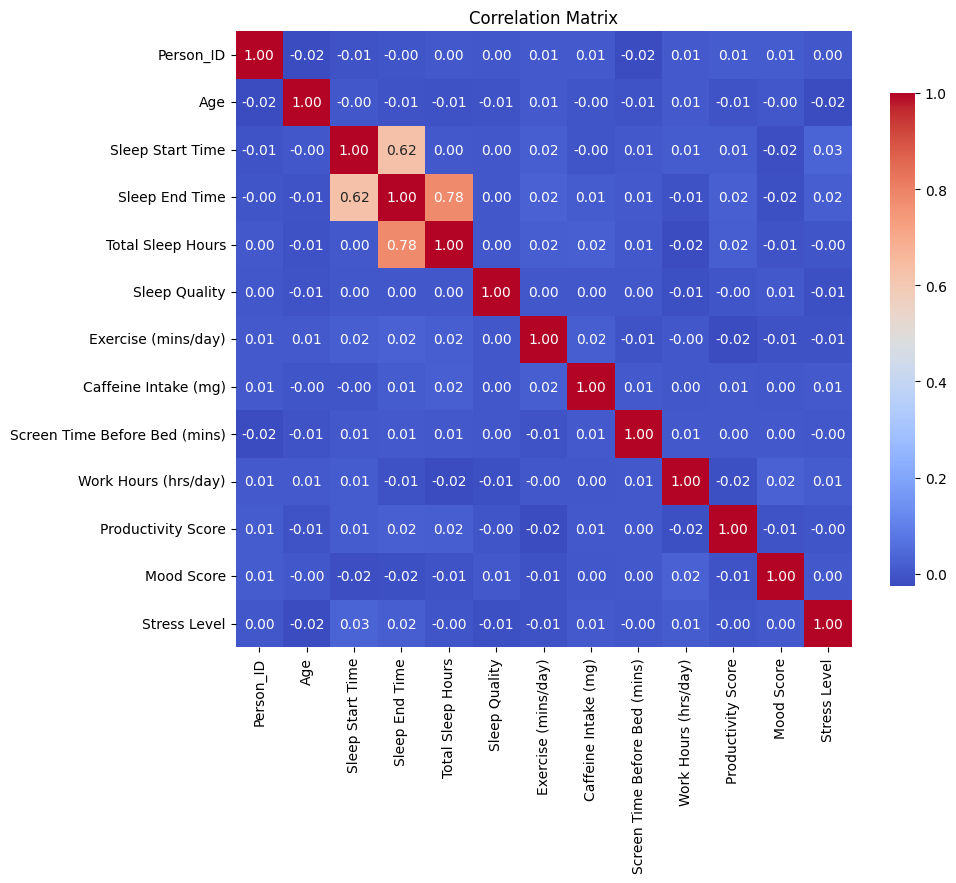

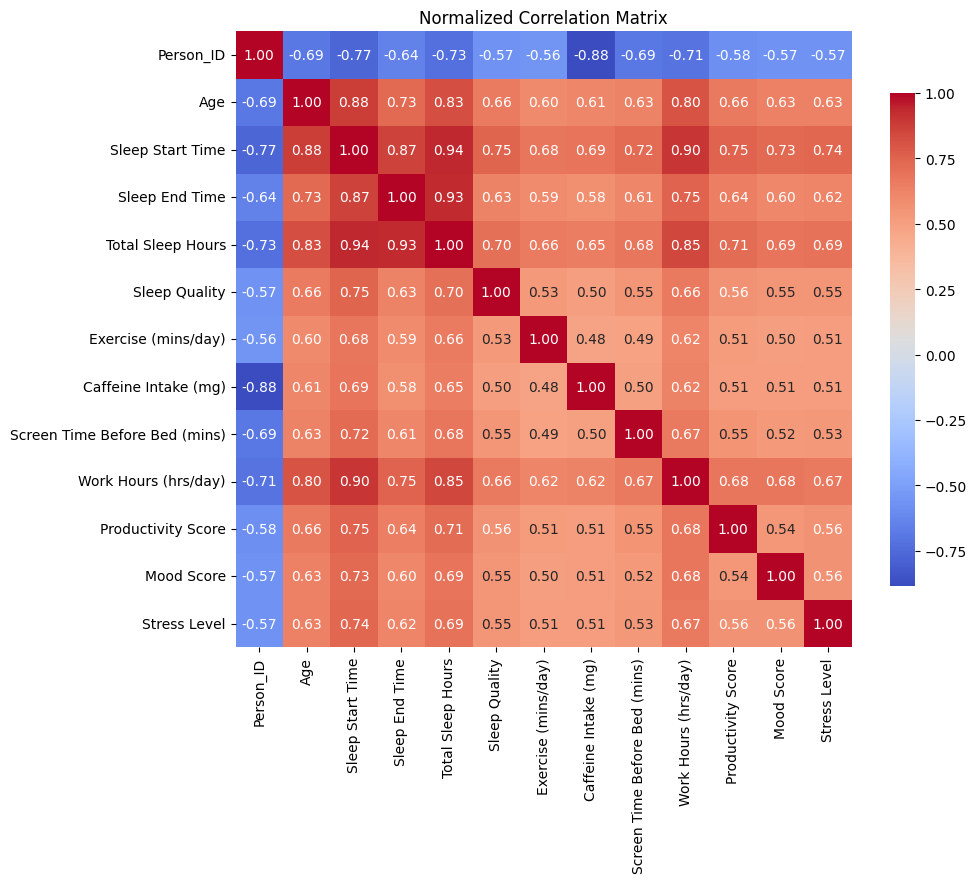

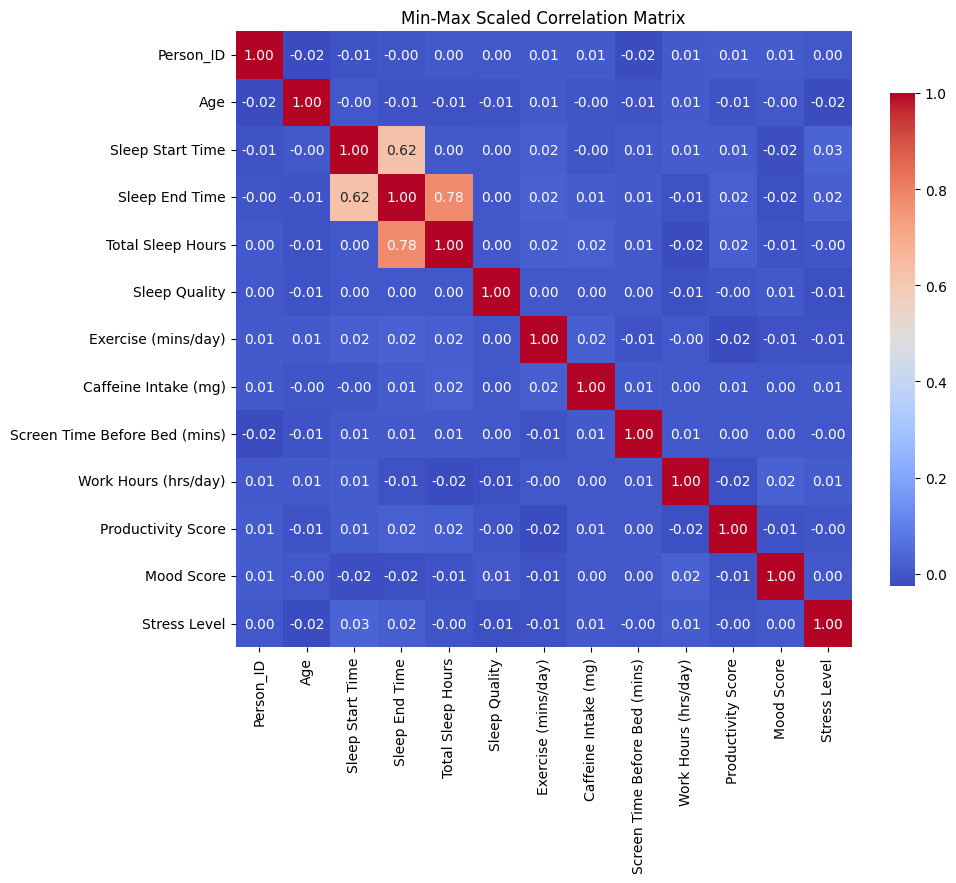

In [64]:
# plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(sleepcycle_dataframe.select_dtypes(exclude='object').corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.show()

# plot normalized correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(sleepcycle_dataframe_normalized.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Normalized Correlation Matrix')
plt.show()

# plot min-max scaled correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(sleepcycle_dataframe_minmax.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Min-Max Scaled Correlation Matrix')
plt.show()

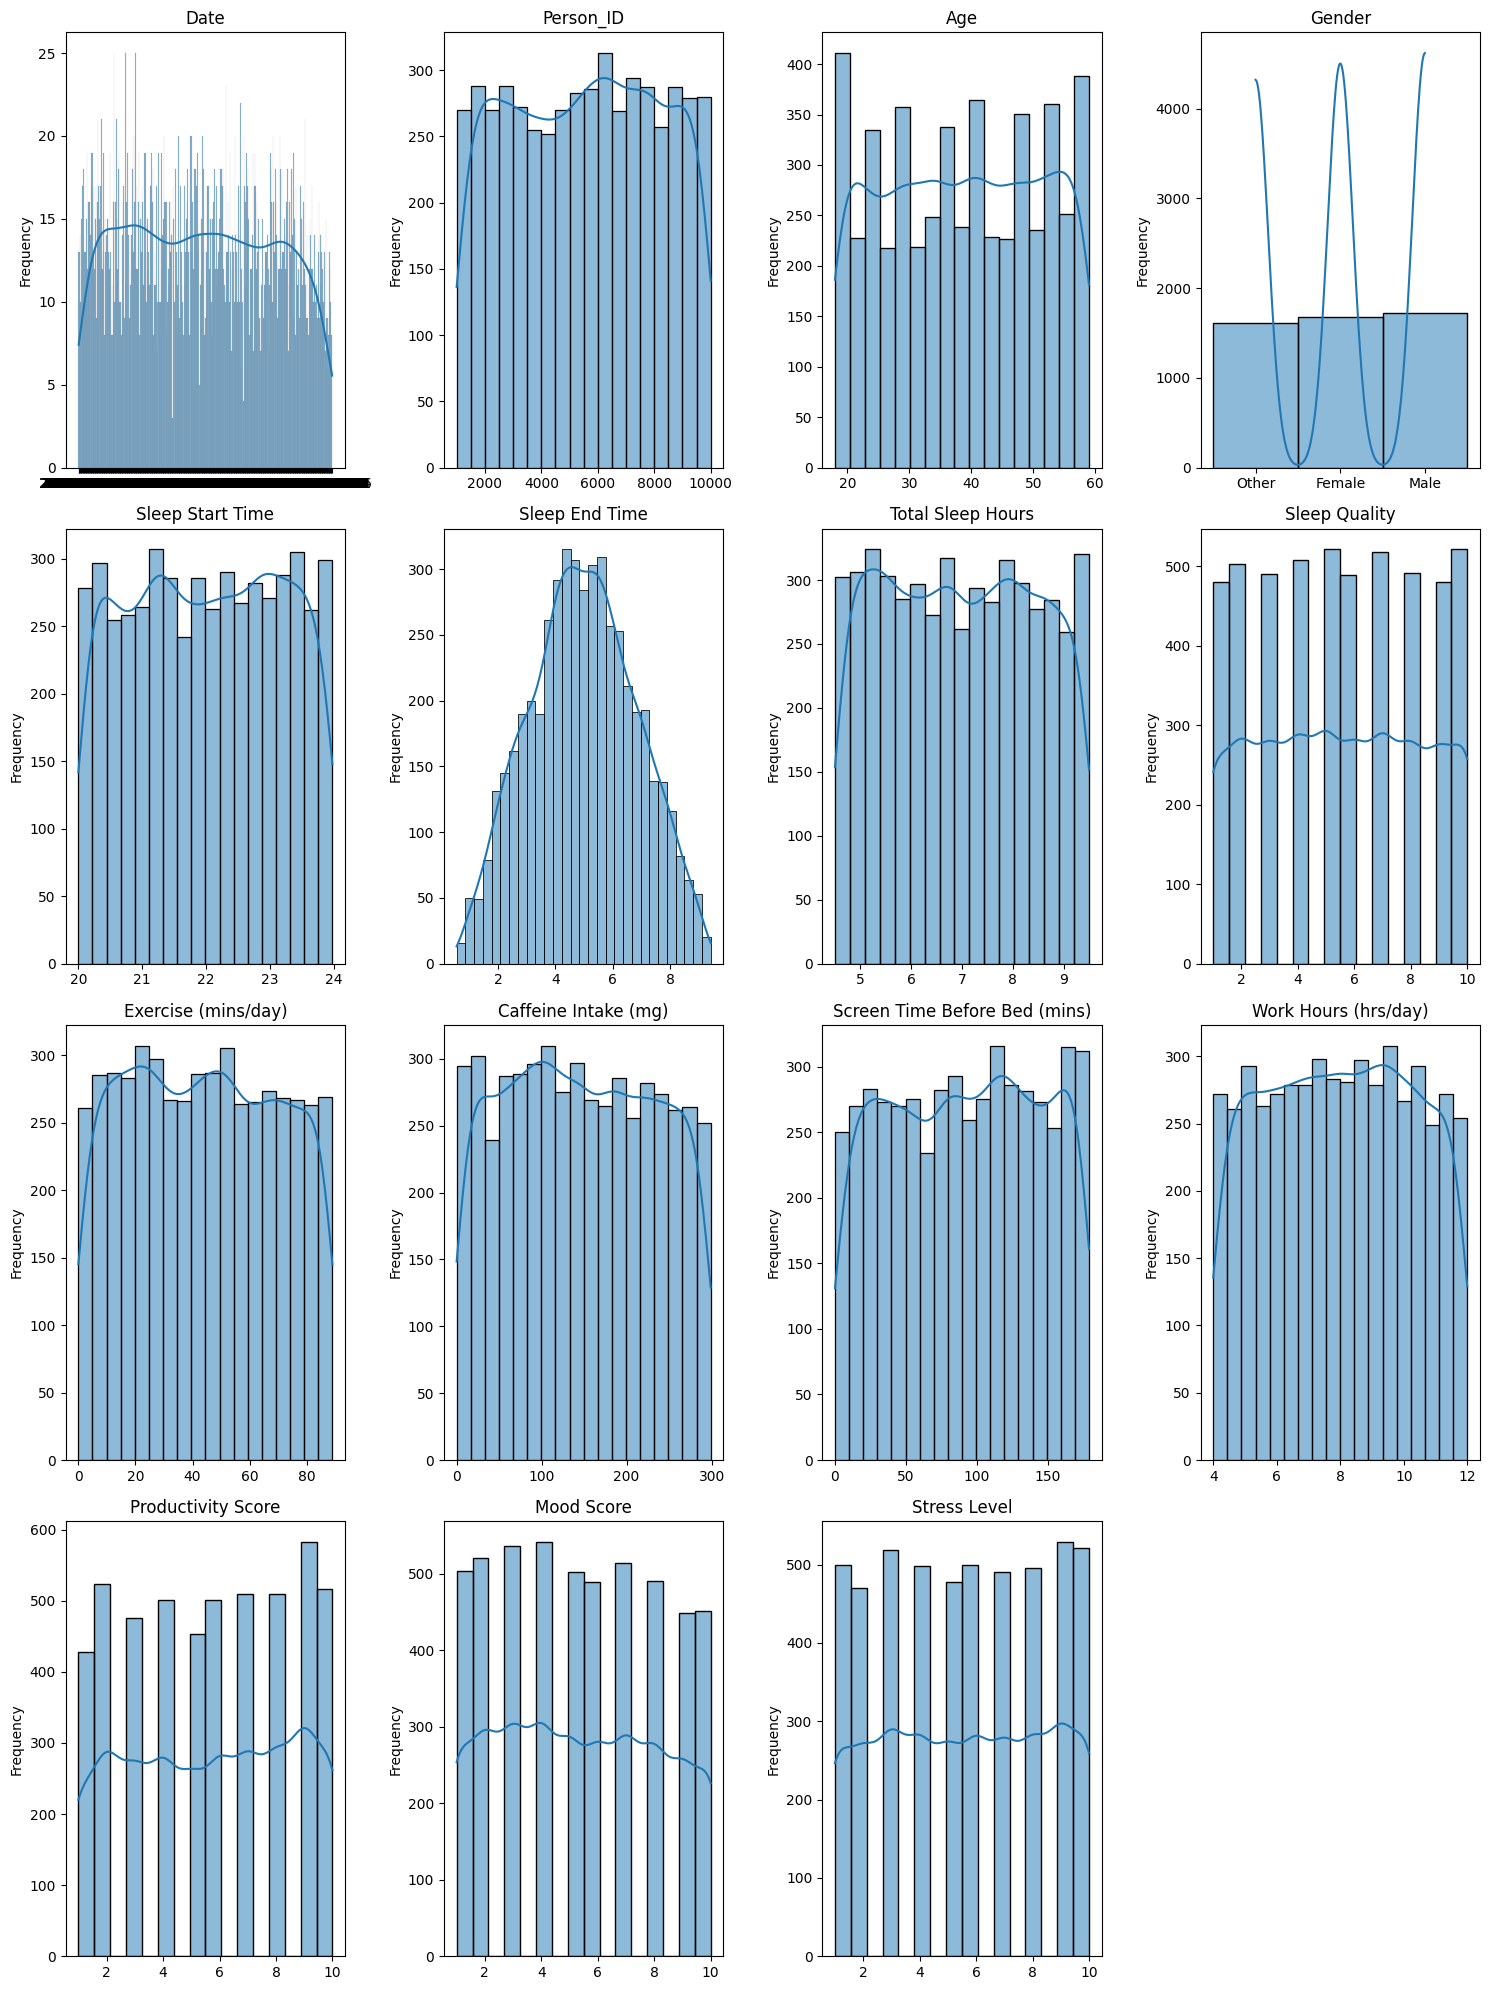

In [65]:
import math

# plot distribution of each feature
num_features = len(sleepcycle_dataframe.columns)
num_rows = math.ceil(num_features / 4)  # Adjust rows dynamically
plt.figure(figsize=(15, 5 * num_rows))
for i, col in enumerate(sleepcycle_dataframe.columns):
    plt.subplot(num_rows, 4, i + 1)
    sns.histplot(sleepcycle_dataframe[col], kde=True)
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

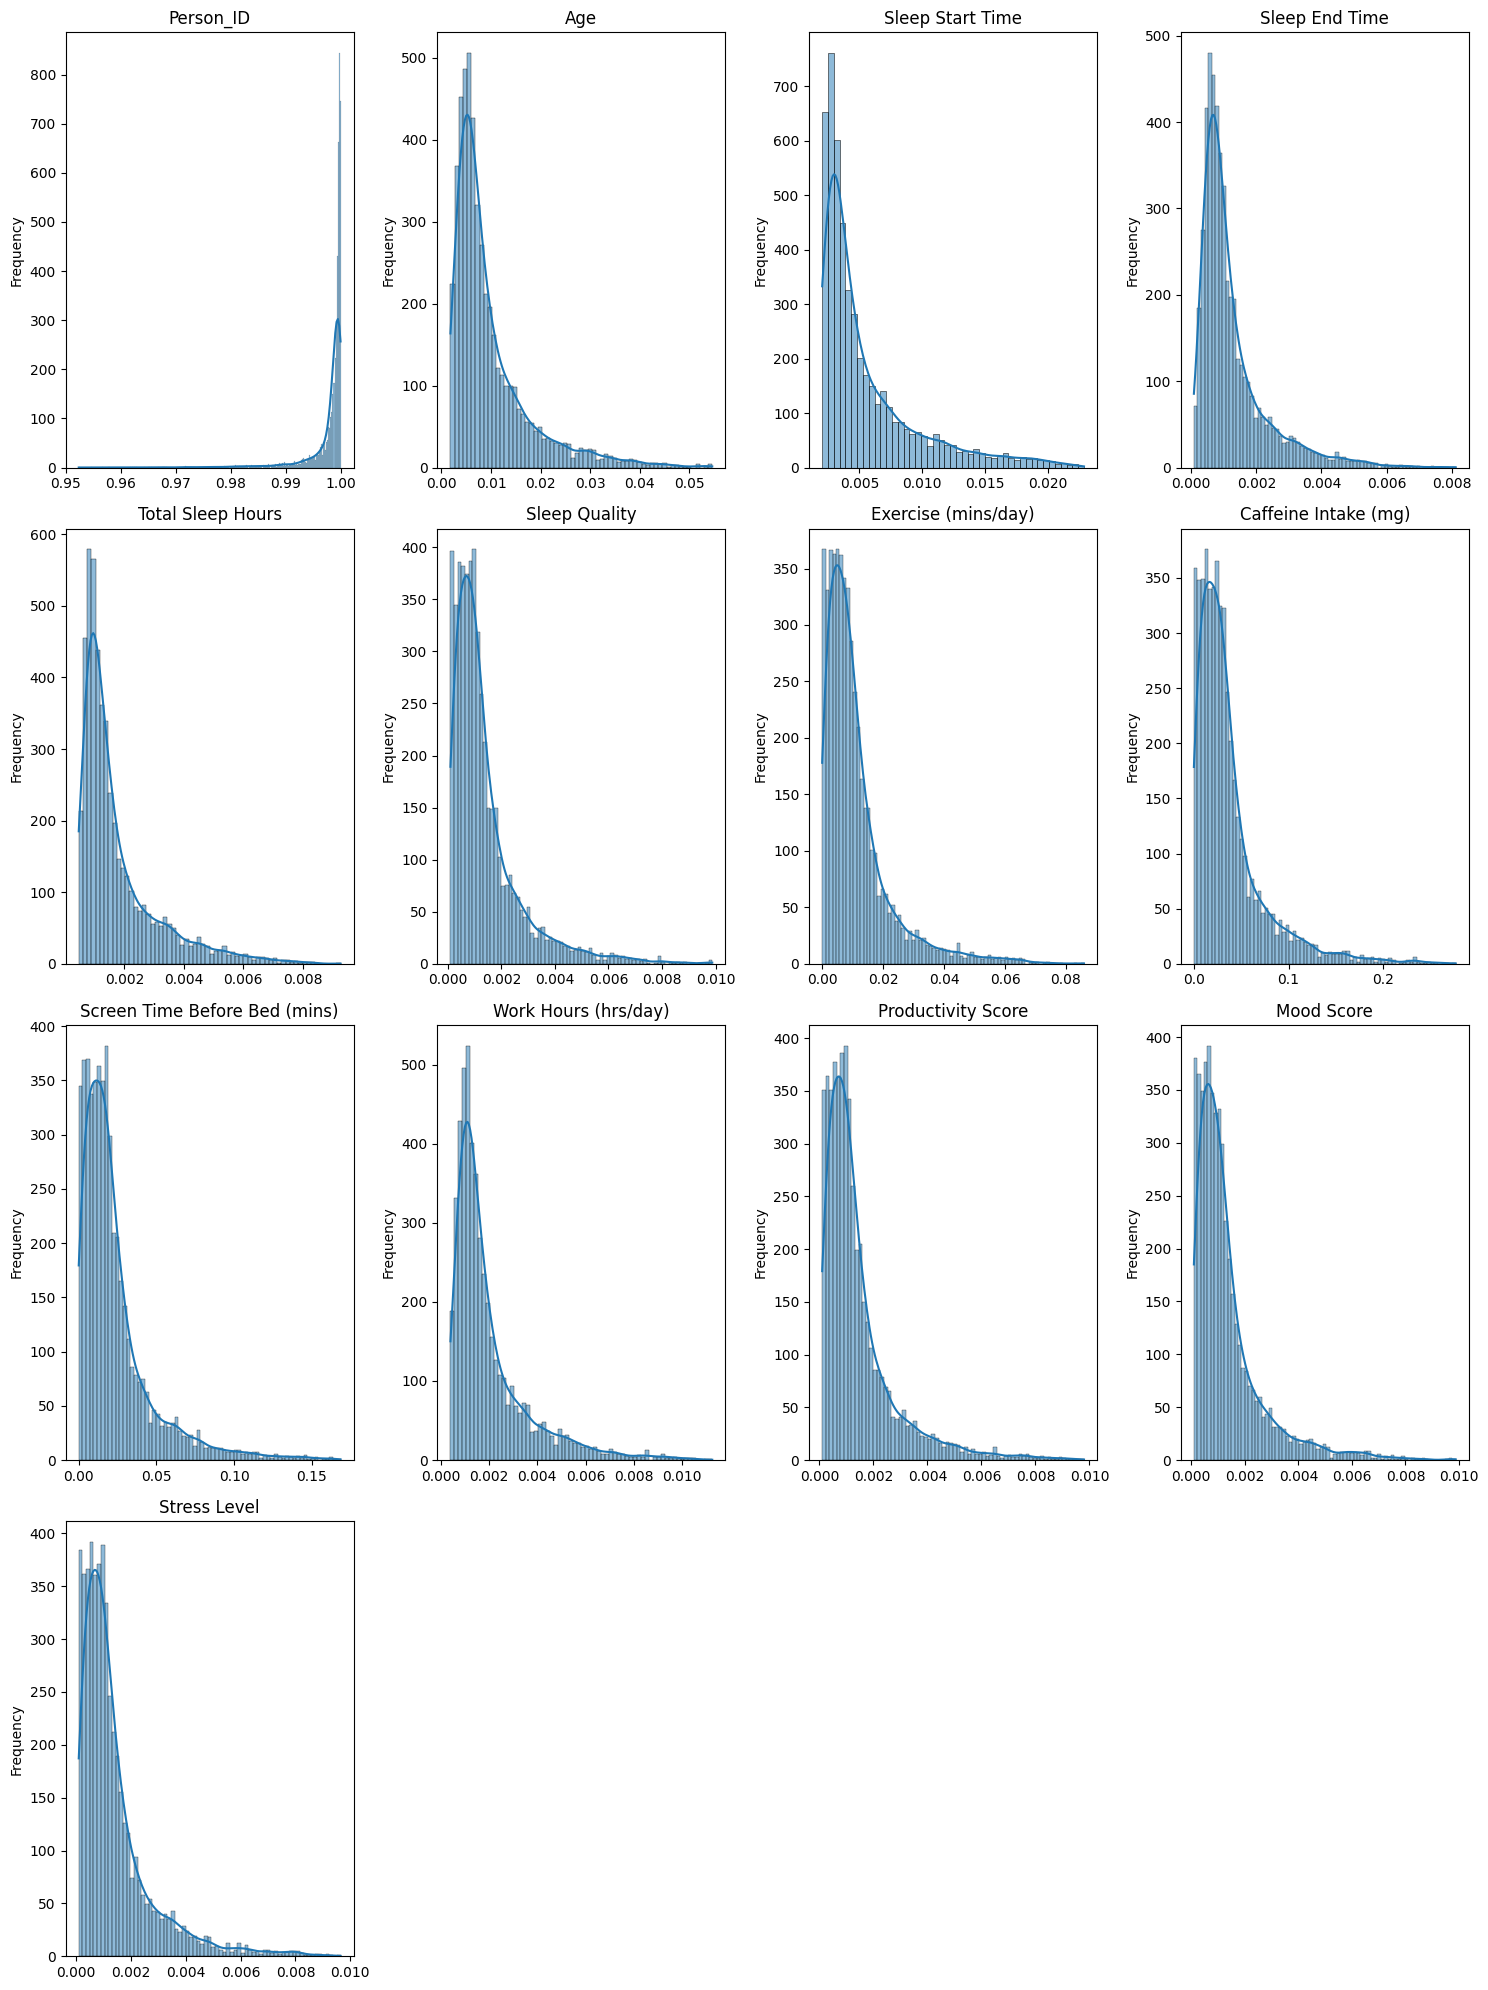

In [66]:
# plot distribution of each feature in normalized dataframe
num_features_normalized = len(sleepcycle_dataframe_normalized.columns)
num_rows_normalized = math.ceil(num_features_normalized / 4)  # Adjust rows dynamically
plt.figure(figsize=(15, 5 * num_rows_normalized))
for i, col in enumerate(sleepcycle_dataframe_normalized.columns):
    plt.subplot(num_rows_normalized, 4, i + 1)
    sns.histplot(sleepcycle_dataframe_normalized[col], kde=True)
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

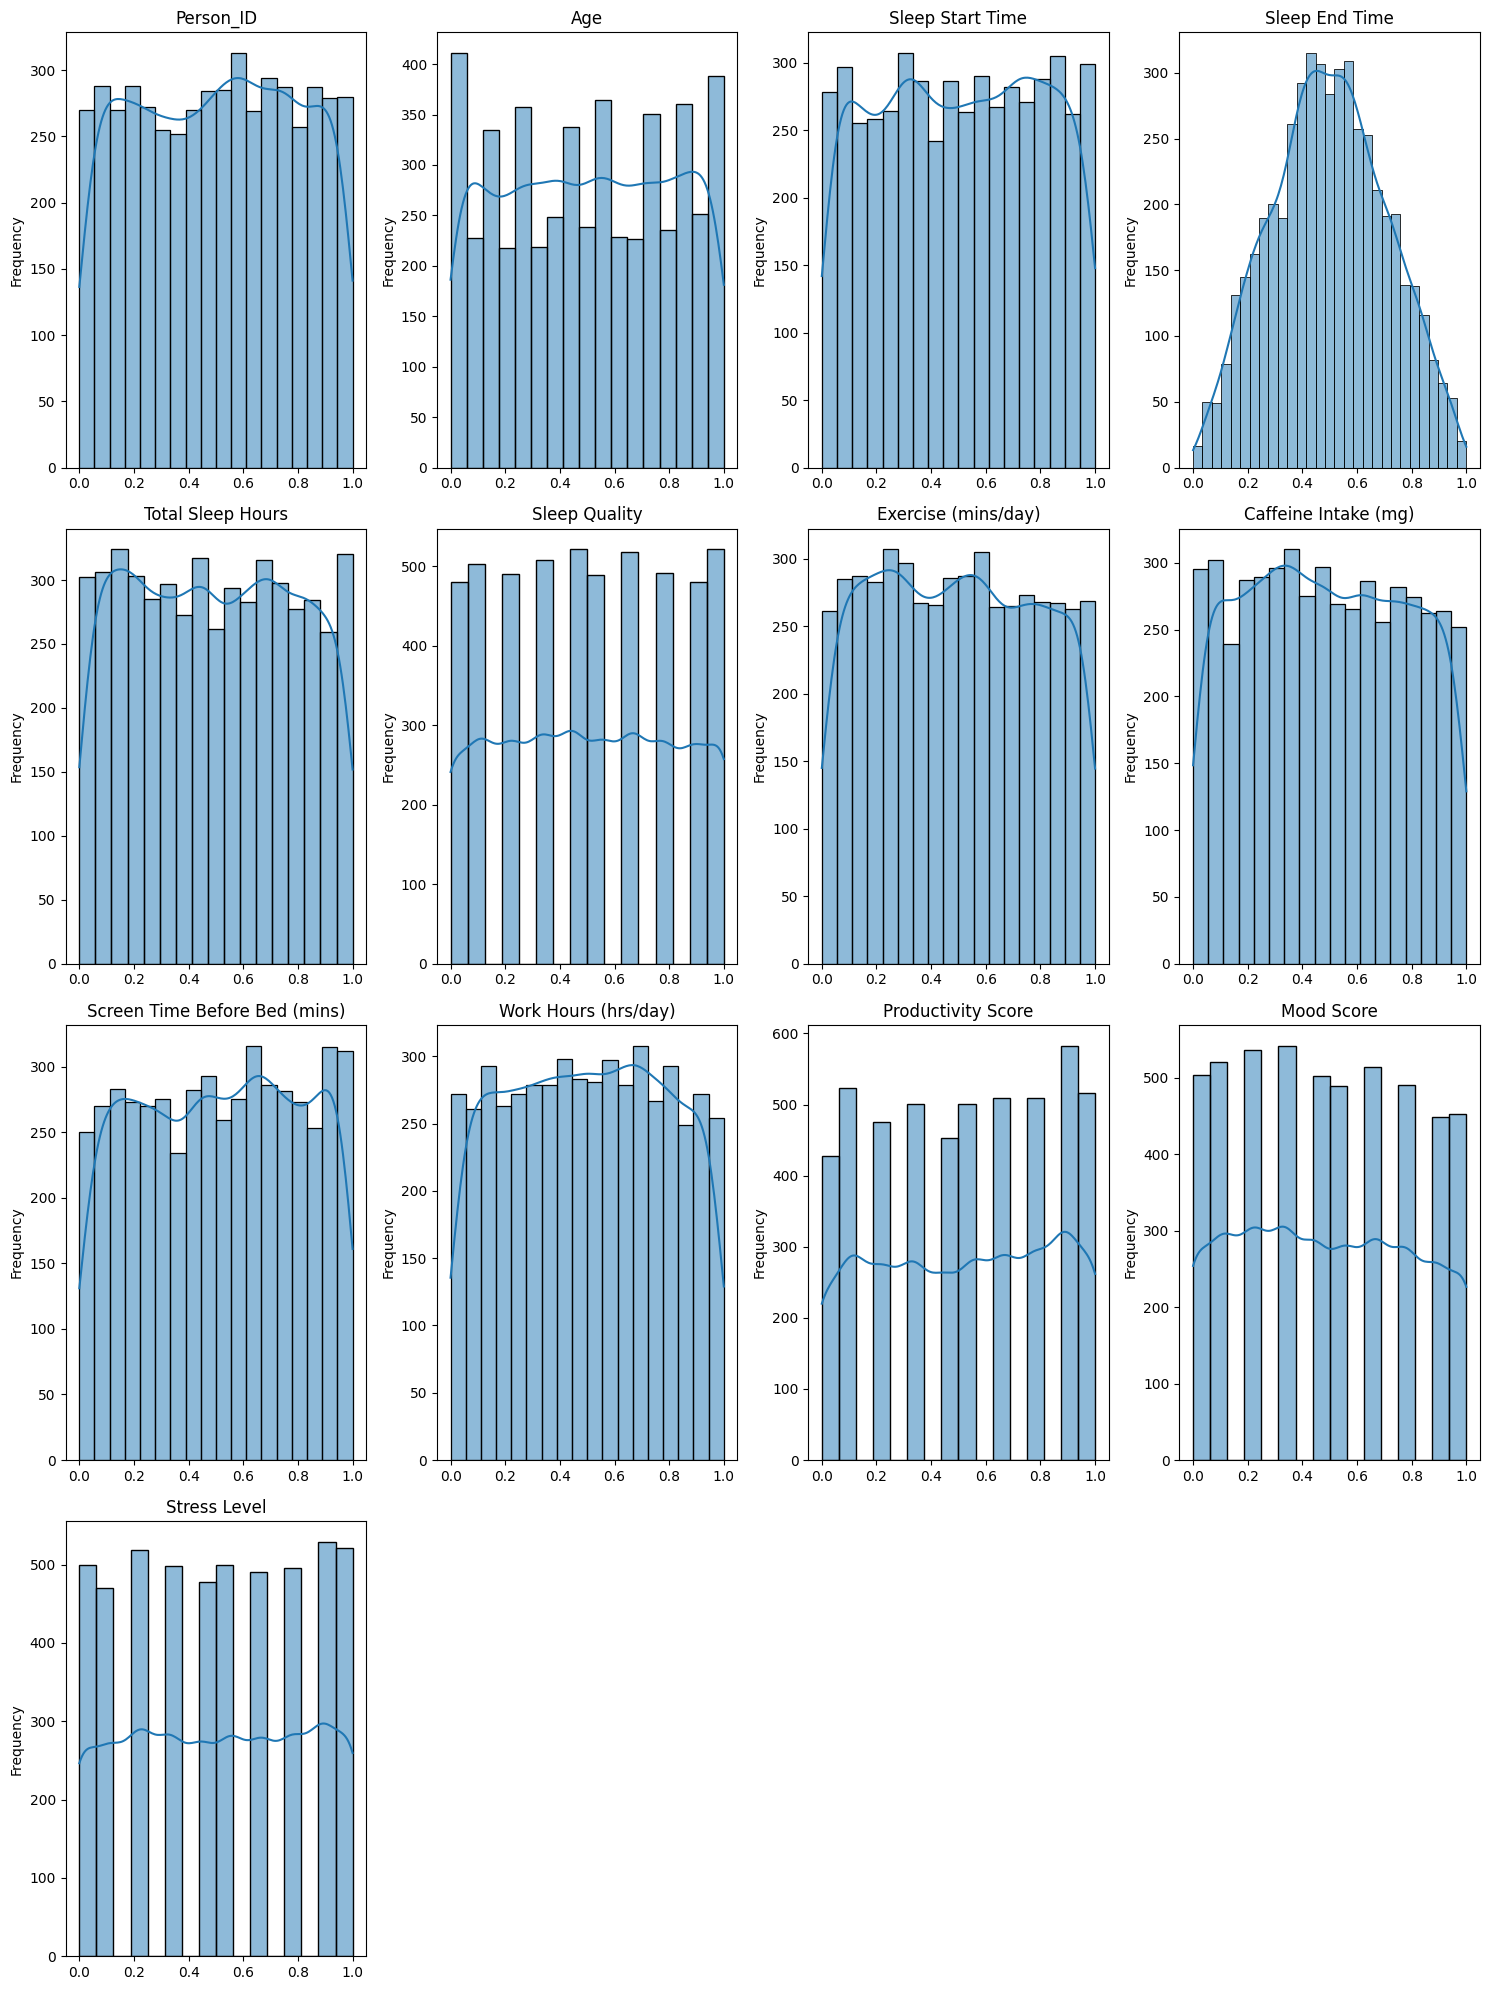

In [67]:
# plot distribution of each feature in min-max scaled dataframe
num_features_minmax = len(sleepcycle_dataframe_minmax.columns)
num_rows_minmax = math.ceil(num_features_minmax / 4)  # Adjust rows dynamically
plt.figure(figsize=(15, 5 * num_rows_minmax))
for i, col in enumerate(sleepcycle_dataframe_minmax.columns):
    plt.subplot(num_rows_minmax, 4, i + 1)
    sns.histplot(sleepcycle_dataframe_minmax[col], kde=True)
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

I can see that the ranges between different features vary greatly (e.g. self-reported scores being 1-10 while other features like caffeine intake going from 0-300mg). This suggests the need to scale numerical features. In addition, Gender will need encoding to be useful (onehot encoding works since gender is nominal).

### Preparing the Dataset for Training

For this dataset in general, I will be using pipelines and grid search to more effectively determine the highest performing scaler and hyperparameter(s).

In [68]:
# Split dataset into feature and target dataframes
y = sleepcycle_dataframe['Productivity Score']
X = sleepcycle_dataframe.drop(['Productivity Score','Date', 'Person_ID'], axis=1)   # drop ID and Date; likely not informative to sleep quality


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Identify categorical/numerical types for pipeline processing
categorical_columns = ['Gender']
#numerical_columns = ['Age', 'Sleep Start Time', 'Sleep End Time', 'Total Sleep Hours', 'Exercise (mins/day)', 'Caffeine Intake (mg)',
#                     'Screen Time Before Bed (mins)', 'Work Hours (hrs/day)', 'Productivity Score', 'Mood Score', 'Stress Level']
numerical_columns = ['Total Sleep Hours', 'Sleep Start Time', 'Exercise (mins/day)', 'Caffeine Intake (mg)', 'Screen Time Before Bed (mins)', 
                     'Work Hours (hrs/day)', 'Stress Level', 'Sleep Quality', 'Mood Score']

# ColumnTransformer for pipelined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(), categorical_columns)
    ])

# Build pipeline
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

# parameter grid searching for best scaling method
param_grid = {
    'preprocessor__num': [StandardScaler(), RobustScaler(), MinMaxScaler(), Normalizer(), MaxAbsScaler()]
}

In [69]:
grid = GridSearchCV(pipeline, param_grid, cv=5, return_train_score=True)

grid.fit(X_train, y_train)

print(f"Best Train score: {grid.best_estimator_.score(X_train, y_train)}")
print(f"Best scaler: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_}")
print(f"Test score: {grid.score(X_test, y_test)}")

# Predictions
y_pred = grid.predict(X_test)

# Metrics
print(f"\nRMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2: {r2_score(y_test, y_pred)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")


Best Train score: 0.0034527745753780703
Best scaler: {'preprocessor__num': Normalizer()}
Best cross-validation score: -0.00339083007290939
Test score: -0.006449534764163101

RMSE: 2.8533143494101463
R2: -0.006449534764163101
MAE: 2.4824446128320785


In [70]:
sleepcycle_dataframe_normalized.head()

,Person_ID,Age,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
0,0.995659,0.017130,0.012489,0.002468,0.002826,0.001606,0.046036,0.046571,0.062095,0.004715,0.004282,0.001606,0.003212
1,0.998153,0.023134,0.011860,0.001371,0.003053,0.002821,0.018056,0.011849,0.049654,0.003572,0.005642,0.001693,0.003950
2,0.998997,0.007903,0.008733,0.001363,0.002114,0.002766,0.006718,0.034775,0.023315,0.003361,0.003952,0.003557,0.003952
3,0.999908,0.004601,0.002873,0.000827,0.000939,0.000995,0.005720,0.004228,0.009948,0.000755,0.000995,0.000497,0.000249
4,0.998130,0.009480,0.004415,0.000859,0.001391,0.002061,0.012572,0.055440,0.019373,0.002344,0.001649,0.001443,0.001855


In [71]:
# split normalized data into feature and target dataframes
X_normalized = sleepcycle_dataframe_normalized.drop(['Productivity Score', 'Person_ID'], axis=1)   
y_normalized = sleepcycle_dataframe_normalized['Productivity Score']

# Train/test split
X_train_normalized, X_test_normalized, y_train_normalized, y_test_normalized = train_test_split(X_normalized, y_normalized, test_size=0.2, random_state=0)

# ColumnTransformer for pipelined preprocessing
preprocessor_normalized = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns)
    ])

# Build pipeline
pipeline_normalized = Pipeline(
    steps=[
        ('preprocessor', preprocessor_normalized),
        ('model', LinearRegression())
    ]
)

# parameter grid searching for best scaling method  
param_grid_normalized = {
    'preprocessor__num': [StandardScaler(), RobustScaler(), MinMaxScaler(), Normalizer(), MaxAbsScaler()]
}
# scale test set
X_train_scaled_normalized = preprocessor_normalized.fit_transform(X_train_normalized)
X_test_scaled_normalized = preprocessor_normalized.transform(X_test_normalized)

grid_normalized = GridSearchCV(pipeline_normalized, param_grid_normalized, cv=5, return_train_score=True)
grid_normalized.fit(X_train_normalized, y_train_normalized)

print(f"Best scaler (normalized): {grid_normalized.best_params_}")
print(f"Best cross-validation score (normalized): {grid_normalized.best_score_}")

# Predictions
y_pred_normalized = grid_normalized.predict(X_test_normalized)

# Metrics
print(f"\nRMSE (normalized): {root_mean_squared_error(y_test_normalized, y_pred_normalized)}")
print(f"R2 (normalized): {r2_score(y_test_normalized, y_pred_normalized)}")
print(f"MAE (normalized): {mean_absolute_error(y_test_normalized, y_pred_normalized)}")

Best scaler (normalized): {'preprocessor__num': StandardScaler()}
Best cross-validation score (normalized): 0.5589797153354665

RMSE (normalized): 0.0009098519640294205
R2 (normalized): 0.5681728032684245
MAE (normalized): 0.0006337348944375374


In [72]:
# split min-max scaled data into feature and target dataframes
X_minmax = sleepcycle_dataframe_minmax.drop(['Productivity Score', 'Age', 'Person_ID'], axis=1)   # ID and Date already dropped
y_minmax = sleepcycle_dataframe_minmax['Productivity Score']

# Train/test split
X_train_minmax, X_test_minmax, y_train_minmax, y_test_minmax = train_test_split(X_minmax, y_minmax, test_size=0.2, random_state=0)

# ColumnTransformer for pipelined preprocessing
preprocessor_minmax = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns)
    ])

# Build pipeline
pipeline_minmax = Pipeline(
    steps=[
        ('preprocessor', preprocessor_minmax),
        ('model', LinearRegression())
    ]
)

# parameter grid searching for best scaling method
param_grid_minmax = {
    'preprocessor__num': [StandardScaler(), RobustScaler(), MinMaxScaler(), Normalizer(), MaxAbsScaler()]
}

# scale test set
X_train_scaled_minmax = preprocessor_minmax.fit_transform(X_train_minmax)
X_test_scaled_minmax = preprocessor_minmax.transform(X_test_minmax)

grid_minmax = GridSearchCV(pipeline_minmax, param_grid_minmax, cv=5, return_train_score=True)
grid_minmax.fit(X_train_minmax, y_train_minmax)

print(f"Best scaler (min-max): {grid_minmax.best_params_}")
print(f"Best cross-validation score (min-max): {grid_minmax.best_score_}")
print(f"Test score (min-max): {grid_minmax.score(X_test_minmax, y_test_minmax)}")

# Predictions
y_pred_minmax = grid_minmax.predict(X_test_minmax)

# Metrics
print(f"\nRMSE (min-max): {root_mean_squared_error(y_test_minmax, y_pred_minmax)}")
print(f"R2 (min-max): {r2_score(y_test_minmax, y_pred_minmax)}")
print(f"MAE (min-max): {mean_absolute_error(y_test_minmax, y_pred_minmax)}")

Best scaler (min-max): {'preprocessor__num': Normalizer()}
Best cross-validation score (min-max): -0.0010277811584648911
Test score (min-max): -0.010135822126601912

RMSE (min-max): 0.31761499339856075
R2 (min-max): -0.010135822126601912
MAE (min-max): 0.2761688607705764


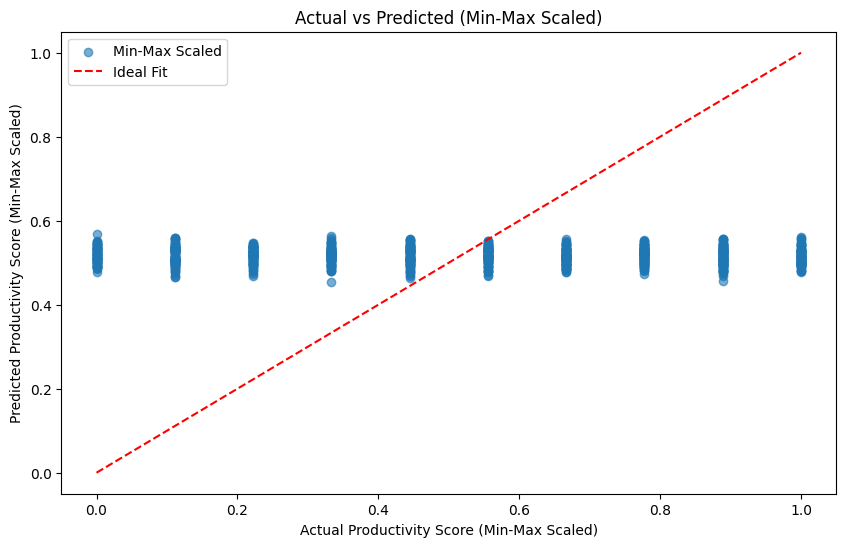

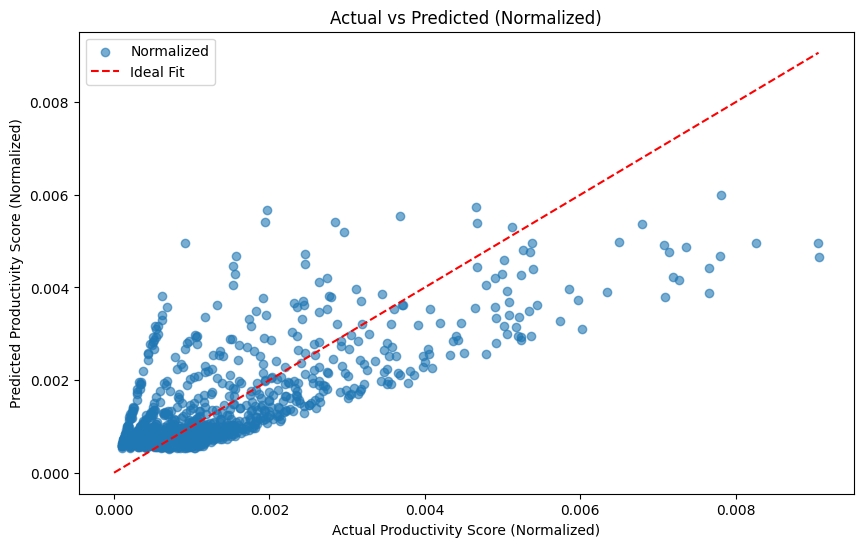

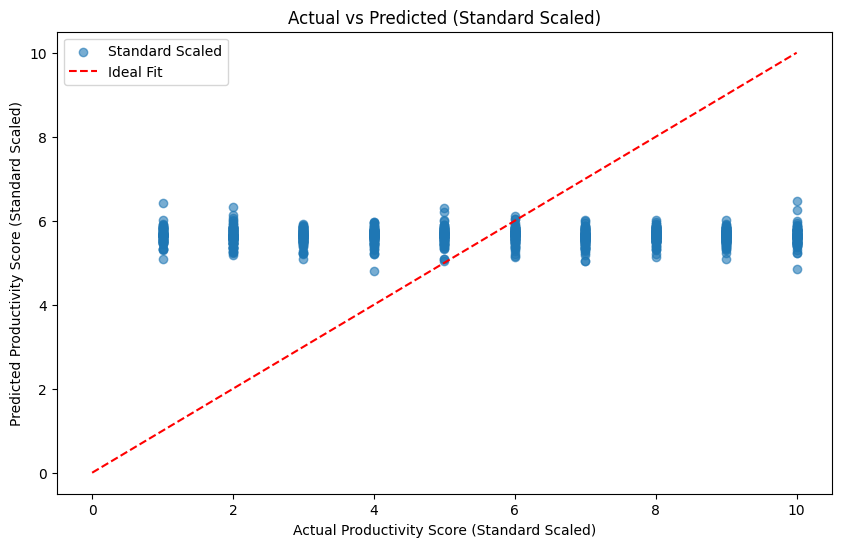

In [74]:
# Plot for min-max scaled data
plt.figure(figsize=(10, 6))
plt.scatter(y_test_minmax, y_pred_minmax, alpha=0.6, label='Min-Max Scaled')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('Actual Productivity Score (Min-Max Scaled)')
plt.ylabel('Predicted Productivity Score (Min-Max Scaled)')
plt.title('Actual vs Predicted (Min-Max Scaled)')
plt.legend()
plt.show()

# Plot for normalized data
plt.figure(figsize=(10, 6))
plt.scatter(y_test_normalized, y_pred_normalized, alpha=0.6, label='Normalized')
plt.plot([0, max(y_test_normalized.max(), y_pred_normalized.max())], 
         [0, max(y_test_normalized.max(), y_pred_normalized.max())], 
         color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('Actual Productivity Score (Normalized)')
plt.ylabel('Predicted Productivity Score (Normalized)')
plt.title('Actual vs Predicted (Normalized)')
plt.legend()
plt.show()

# Plot for standard scaled data
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label='Standard Scaled')
plt.plot([0, max(y_test.max(), y_pred.max())], 
         [0, max(y_test.max(), y_pred.max())], 
         color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('Actual Productivity Score (Standard Scaled)')
plt.ylabel('Predicted Productivity Score (Standard Scaled)')
plt.title('Actual vs Predicted (Standard Scaled)')
plt.legend()
plt.show()